In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Datasets/AIML Dataset.csv")

In [3]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

*   ***step***: Represents a unit of time in the real world (1 step is 1 hour). It denotes the portion of the time period the transaction occurredList item
*   ***nameOrig***:  unique ID of sender      
* ***oldbalanceOrg***: The initial balance of the sender before the transaction
* ***newbalanceOrig***: The new balance of the sender after the transaction
* ***nameDest***: The unique ID of the recipient account.      
* ***oldbalanceDest***: The initial balance of the recipient before the transaction
* ***newbalanceDest***: The new balance of the recipient after the transaction
* ***isFraud***: The target variable for your model. A value of 1 indicates a fraudulent transaction, while 0 indicates it is legitimate
* ***isFlaggedFraud***: A flag set by the existing system to mark suspicious activity, typically for large transfers (e.g., over 200,000 units)



In [4]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(6362620, 11)

In [9]:
print(df["isFraud"].value_counts())
print(df["isFlaggedFraud"].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [10]:
round((df['isFraud'].value_counts()[1] / df.shape[0]) * 100,2)
# the percentage of fruad trasaction in our dataset.
# no. of fraud transaction / total transaction * 100

np.float64(0.13)

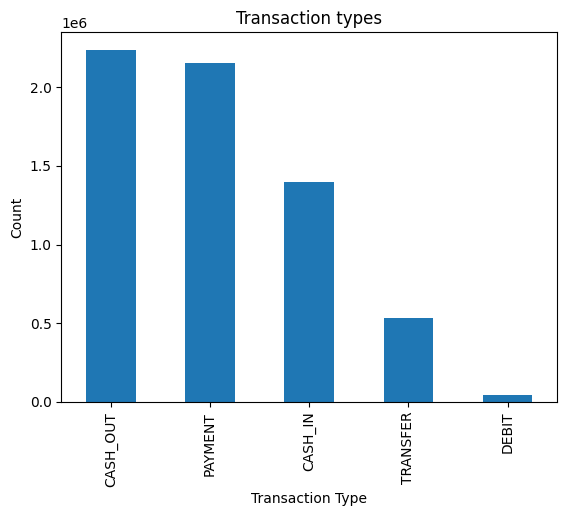

In [11]:
import matplotlib.pyplot as plt

df['type'].value_counts().plot(kind='bar', title='Transaction types')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

In [12]:
frud_by_type = df.groupby('type')['isFraud'].mean()
print(frud_by_type)
#which type of trasaction is seen mainly in fraud

type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.007688
Name: isFraud, dtype: float64


In [13]:
df['amount'].describe().astype(int)
#statistical values of amount

,amount
count,6362620
mean,179861
std,603858
min,0
25%,13389
50%,74871
75%,208721
max,92445516


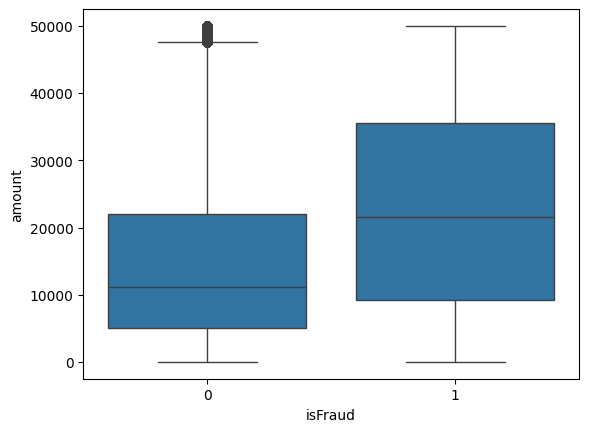

In [14]:
import seaborn as sns
sns.boxplot(x='isFraud', y='amount', data=df[df['amount'] < 50000])
plt.show()
#the relation b/w  amount and fraud

In [15]:
df['diffsender'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['diffreceiver'] = df['oldbalanceDest'] - df['newbalanceDest']
#to check the anomalities and balance chain

In [16]:
print((df['diffsender'] < 0).sum())
print((df['diffreceiver'] < 0).sum())
#we have multiple negetive values in our sender and reciver diffrenced.

1399253
2806464


In [17]:
df.groupby(df['diffsender'] < 0)['isFraud'].mean()

,isFraud
diffsender,
False,0.001655
True,0.000000


In [18]:
df.groupby(df['diffreceiver'] < 0)['isFraud'].mean()

,isFraud
diffreceiver,
False,0.001157
True,0.001461


Sender and receiver balance differences showed that negative sender differences were not associated with fraudulent transactions, while negative receiver differences showed only a marginal increase in fraud rate.

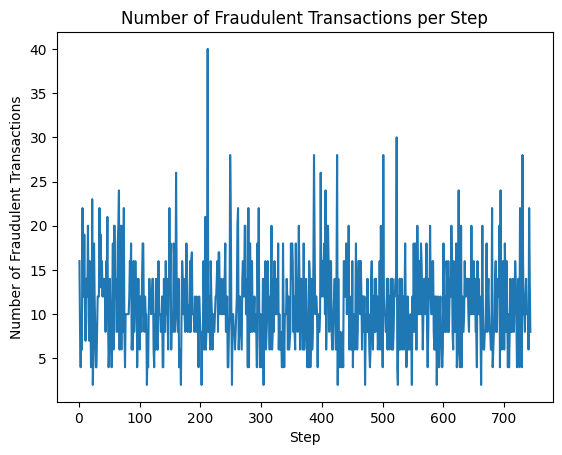

In [19]:
fraud_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(fraud_per_step.index, fraud_per_step.values)
plt.xlabel('Step')
plt.ylabel('Number of Fraudulent Transactions')
plt.title('Number of Fraudulent Transactions per Step')
plt.show()

In [20]:
df[['step', 'isFraud']].corr()

,step,isFraud
step,1.000000,0.031578
isFraud,0.031578,1.000000


Fraud occurrence varies across transaction steps, indicating that fraudulent activities are not uniformly distributed over time

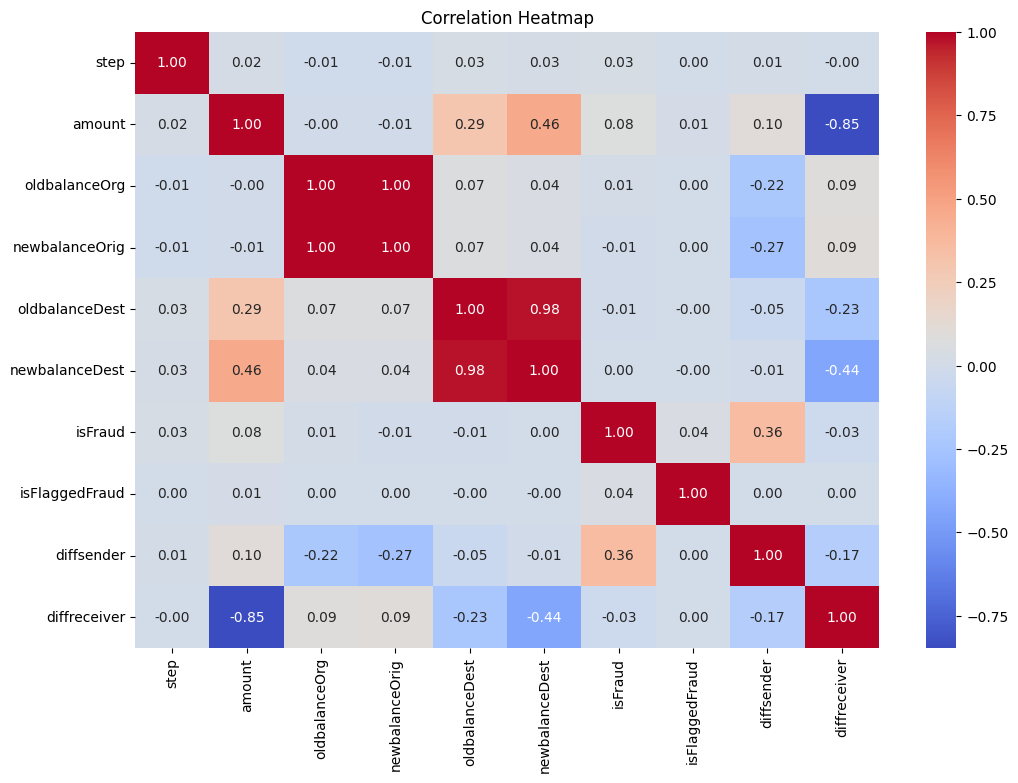

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix
corr_matrix = df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [22]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


In [23]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,diffsender,diffreceiver
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [24]:
df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)

In [25]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,diffsender,diffreceiver
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,21182.0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [26]:
x = df.drop(columns=['isFraud'])
y = df['isFraud']

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_cols = ['type']

numerical_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'diffsender', 'diffreceiver']

preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)])

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_smote, y_train_smote = smote.fit_resample(x_train_processed, y_train)

In [30]:
x_train_smote

array([[ 0.        ,  0.        ,  0.        , ..., -0.30114711,
        -2.4714832 ,  0.62971161],
       [ 0.        ,  0.        ,  0.        , ..., -0.17188343,
        -1.29447372,  0.41519567],
       [ 0.        ,  0.        ,  1.        , ..., -0.33378152,
         0.16788859,  0.15315483],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.11637236,
        11.3122531 , -1.88244401],
       [ 0.        ,  0.        ,  0.        , ..., -0.33378152,
         6.5451707 ,  0.15315483],
       [ 0.        ,  0.        ,  0.        , ..., -0.33378152,
         3.77723626,  0.15315483]])

In [31]:
print(y_train.value_counts())

print(y_train_smote.value_counts())


isFraud
0    5083503
1       6593
Name: count, dtype: int64
isFraud
0    5083503
1    5083503
Name: count, dtype: int64


In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(x_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [33]:
y_pred = model.predict(x_test_processed)

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1270904
           1       0.02      0.95      0.05      1620

    accuracy                           0.95   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [35]:
model.score(x_test_processed, y_test)

0.9504638026473371

In [36]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[1207945,   62959],
       [     77,    1543]])

In [37]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score

# No SMOTE needed — XGBoost handles it via scale_pos_weight
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=6354407/8213,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='aucpr'
    ))
])

pipeline.fit(x_train, y_train)
y_pred_proba = pipeline.predict_proba(x_test)[:, 1]
print(f"PR-AUC: {average_precision_score(y_test, y_pred_proba):.4f}")

PR-AUC: 0.9683


In [38]:
y_pred = pipeline.predict(x_test)

In [39]:
confusion_matrix(y_test, y_pred)

array([[1268909,    1995],
       [     14,    1606]])

In [40]:
pipeline.score(x_test, y_test)

0.9984212478507282

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.45      0.99      0.62      1620

    accuracy                           1.00   1272524
   macro avg       0.72      0.99      0.81   1272524
weighted avg       1.00      1.00      1.00   1272524



In [42]:
 import numpy as np
from sklearn.metrics import precision_recall_curve

y_probs = pipeline.predict_proba(x_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

Best Threshold: 0.99409384
Best F1: 0.9166936785936445


In [43]:
y_pred_opt = (y_probs >= best_threshold).astype(int)

In [44]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))

[[1270853      51]
 [    206    1414]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.97      0.87      0.92      1620

    accuracy                           1.00   1272524
   macro avg       0.98      0.94      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524



In [45]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=6354407/8213,
    eval_metric='aucpr',
    random_state=42
)

param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

In [46]:
pipeline_tuned = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb)
])

In [47]:
import joblib

joblib.dump(pipeline, 'fraud_model.pkl')

['fraud_model.pkl']

In [48]:
%%writefile app.py

Writing app.py


In [49]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load('fraud_model.pkl')

st.title("Fraud Detection App")

st.write("Enter transaction details:")

# User Inputs
step = st.number_input("Step", min_value=0)

transaction_type = st.selectbox(
    "Transaction Type",
    ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
)

amount = st.number_input("Amount", min_value=0.0)

oldbalanceOrg = st.number_input("Old Balance Origin", min_value=0.0)

newbalanceOrig = st.number_input("New Balance Origin", min_value=0.0)

oldbalanceDest = st.number_input("Old Balance Destination", min_value=0.0)

newbalanceDest = st.number_input("New Balance Destination", min_value=0.0)

# Feature engineering
diffsender = newbalanceOrig - (oldbalanceOrg - amount)

diffreceiver = newbalanceDest - (oldbalanceDest + amount)

# Prediction button
if st.button("Predict Fraud"):

    input_data = pd.DataFrame({
        'step': [step],
        'type': [transaction_type],
        'amount': [amount],
        'oldbalanceOrg': [oldbalanceOrg],
        'newbalanceOrig': [newbalanceOrig],
        'oldbalanceDest': [oldbalanceDest],
        'newbalanceDest': [newbalanceDest],
        'diffsender': [diffsender],
        'diffreceiver': [diffreceiver]
    })

    prediction = model.predict(input_data)[0]

    probability = model.predict_proba(input_data)[0][1]

    if prediction == 1:
        st.error(f"Fraud Detected! Probability: {probability:.2f}")
    else:
        st.success(f"Legitimate Transaction. Probability: {probability:.2f}")

Overwriting app.py


In [50]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 67.5 MB/s eta 0:00:00


In [51]:
!pip install pyngrok

In [52]:
!streamlit run app.py &>/content/logs.txt &

In [53]:
from pyngrok import ngrok

ngrok.set_auth_token("3E6sSWRyiHPFgiV4MyAKhY9rtgb_5DSshUis1i8Dmc7HfnQRV")

In [54]:
!streamlit run app.py &>/content/logs.txt &

In [55]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://scribble-preachy-vest.ngrok-free.dev" -> "http://localhost:8501"


In [56]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
xgboost
joblib

Writing requirements.txt


In [57]:
from google.colab import files

files.download('app.py')
files.download('fraud_model.pkl')
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>